In [6]:
"This notebook is for selection genes that show bimodal distributions in the corresponding processes."

'This notebook is for selection genes that show bimodal distributions in the corresponding processes.'

In [ ]:
# import scvelo as scv
# import pandas as pd 
# import numpy as np
# from anndata import AnnData
# import loompy
# from matplotlib import pyplot as plt
# from sklearn.preprocessing import StandardScaler,MinMaxScaler
# import matplotlib.patches as mpatches
# import pickle
# import os
# import leidenalg
# from scipy import sparse
# from IPython.display import SVG
# from sklearn.linear_model import LinearRegression
# from scipy import stats,signal
# from sklearn.preprocessing import StandardScaler,MinMaxScaler
# from sklearn.cross_decomposition import PLSRegression
# from sklearn.feature_selection import f_regression, mutual_info_regression
# from sklearn.cluster import KMeans

# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score
# from filter_dispersion import filter_dispersion
# from scipy.sparse import issparse
# from scvelo.preprocessing.utils import get_mean_var,materialize_as_ndarray
# from sklearn.cluster import MeanShift
# from scipy.stats import gaussian_kde, norm
# from scipy.signal import find_peaks, peak_prominences

In [1]:
import os
import anndata as ad
import matplotlib.pyplot as plt
from filter_dispersion import filter_dispersion
import numpy as np
import scvelo as scv
from scipy.sparse import issparse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
if not os.path.exists('result/'):
    os.makedirs('result/')
result_path='result/'

In [3]:
adata0=scv.read('data/endocrinogenesis_day15.h5ad')

In [4]:
print(adata0)
print("Obs : ", adata0.obs.shape)
print("Var : ", adata0.var.shape)
print("Layers : ", list(adata0.layers.keys()))

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'
Obs :  (3696, 4)
Var :  (27998, 1)
Layers :  ['spliced', 'unspliced']


In [5]:
print(adata0.obs['clusters'].unique())
t_list = adata0.obs['clusters'].unique().tolist()
print(t_list)

['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']
Categories (8, object): ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Beta', 'Alpha', 'Delta', 'Epsilon']
['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']


In [6]:
"selecting the high dispersion genes in the CPT"

'selecting the high dispersion genes in the CPT'

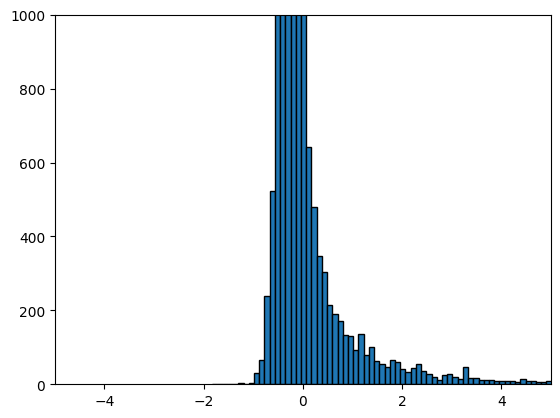

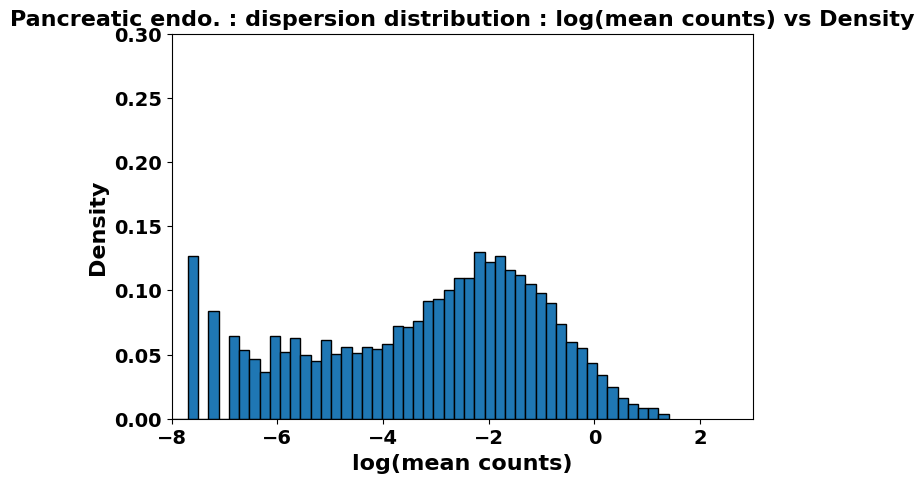

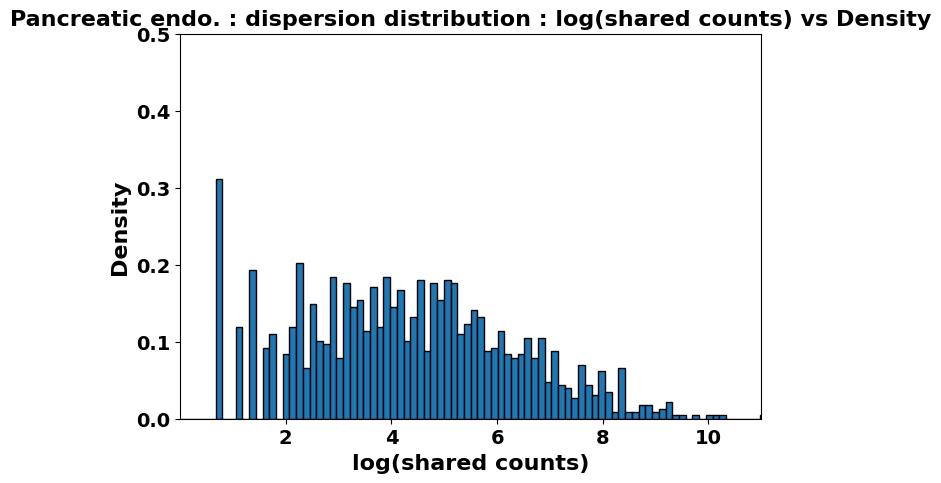

(1272,)

In [8]:
adata=adata0.copy()
adata,df,gene_subset=filter_dispersion(adata,n_bins=20,min_disp = 0.5,max_disp = np.inf,min_mean = 0.01,max_mean = 3)

plt.hist(df["dispersion_norm"].values,bins=200,edgecolor='k')
plt.axis([-5,5,0,1000])
plt.show()

plt.figure(figsize=(7.5,5))
plt.hist(np.log(df["mean"].values),bins=150,edgecolor='k',density=True)
plt.axis([-8,3,0,0.3])
plt.xlabel('log(mean counts)',fontsize=16,fontweight='bold')
plt.ylabel('Density',fontsize=16,fontweight='bold')
plt.title('Pancreatic endo. : dispersion distribution : log(mean counts) vs Density',fontsize=16,fontweight='bold')
plt.xticks(np.arange(-8,3,2),fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold')
plt.savefig(result_path+'EG_mean_counts_distribution.png',dpi=300)
plt.show()

# adata.var.index.values[gene_subset].shape
hv_genes=adata.var.index.values[gene_subset]
adata=adata[:,hv_genes]

#----distribution of shared counts

Xs, Xu = adata.layers["spliced"], adata.layers["unspliced"]
nonzeros = (
    (Xs > 0).multiply(Xu > 0) if issparse(Xs) else (Xs > 0) * (Xu > 0)
            )
X = (
    nonzeros.multiply(Xs) + nonzeros.multiply(Xu)
    if issparse(nonzeros)
                else nonzeros * (Xs + Xu)
            )

# plt.hist(np.sum(X.A,axis=0),bins=100,edgecolor='k')

plt.figure(figsize=(7.5,5))
plt.hist(np.log(np.sum(X.A,axis=0)+1e-6),bins=200,edgecolor='k',density=True)
plt.axis([0,11,0,0.5])
plt.xlabel('log(shared counts)',fontsize=16,fontweight='bold')
plt.ylabel('Density',fontsize=16,fontweight='bold')
plt.title('Pancreatic endo. : dispersion distribution : log(shared counts) vs Density',fontsize=16,fontweight='bold')
plt.xticks(np.arange(2,12,2),fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold')
plt.savefig(result_path+'EG_shared_counts_distribution.png',dpi=300)
plt.show()

np.where(np.log(np.sum(X.A,axis=0))>2)[0].shape

In [9]:
print("adata shape:", adata.shape)
print("genes retained:", np.sum(gene_subset))
print(df.head())

adata shape: (3696, 1791)
genes retained: 1791
           mean  dispersion           mean_bin  dispersion_norm
0  1.622060e-03   -0.001354  (-0.00408, 0.204]        -0.387338
1  1.000000e-12         NaN  (-0.00408, 0.204]         0.000000
2  1.000000e-12         NaN  (-0.00408, 0.204]         0.000000
3  1.000000e-12         NaN  (-0.00408, 0.204]         0.000000
4  1.000000e-12         NaN  (-0.00408, 0.204]         0.000000


In [10]:
adata=adata0[:,hv_genes]
scv.pp.filter_and_normalize(adata,min_shared_counts=10)


print(adata.X.shape)
scv.pp.neighbors(adata, n_neighbors=30)
scv.pp.pca(adata,n_comps=50)
scv.pp.moments(adata, n_pcs=50, n_neighbors=30)

scv.tl.umap(adata)
# scv.tl.recover_dynamics(adata)

scv.tl.velocity(adata,mode='stochastic',perc=[5, 95])

scv.tl.velocity_graph(adata,xkey='Ms')

Filtered out 569 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.
Logarithmized X.
(3696, 1222)
computing neighbors
    finished (0:00:04) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [11]:
print(adata.layers.keys())
print(adata.uns.keys())
print(adata)

KeysView(Layers with keys: spliced, unspliced, Ms, Mu, velocity, variance_velocity)
dict_keys(['clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'umap', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'])
AnnData object with n_obs × n_vars = 3696 × 1222
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'highly_variable_genes', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'umap', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
    obsp: 'distances', 'connectivities'


In [12]:
"selecting genes that can be binarized"

'selecting genes that can be binarized'

In [13]:
gene_arr=adata.var.index.values

In [14]:
from critical_bandwidth import critical_bandwidth,critical_bandwidth_m_modes

from sklearn.neighbors import KernelDensity
from scipy.signal import argrelextrema
def best_split(data, I=(-np.inf, np.inf)):
    '''With bimodal data, finding split at lowest density.'''
    h_crit = critical_bandwidth_m_modes(data, 2, I)
    kde = KernelDensity(kernel='gaussian', bandwidth=h_crit).fit(data.reshape(-1, 1))
    x = np.linspace(max(np.min(data), I[0]), min(np.max(data), I[1]), 200)
    y = np.exp(kde.score_samples(x.reshape(-1, 1)))
    modes = argrelextrema(np.hstack([[0], y, [0]]), np.greater)[0]
    ind_min=[]
    if len(modes)>=2: 
        for i in range(len(modes)-1):
            if len(modes[i]-1 + argrelextrema(y[(modes[i]-1):(modes[i+1]-1)], np.less)[0])>0:
                ind_min.append(modes[i]-1 + argrelextrema(y[(modes[i]-1):(modes[i+1]-1)], np.less)[0][0])
#     else:
#         if len(modes[0]-1 + argrelextrema(y[(modes[0]-1):(modes[1]-1)], np.less)[0])>0:
#             ind_min = modes[0]-1 + argrelextrema(y[(modes[0]-1):(modes[1]-1)], np.less)[0]
#     print(ind_min)
    return x[ind_min]

In [15]:
X0_ori=adata.layers['Ms']
X0_bin=X0_ori.copy()
EG_bin_genes_center=[]
EG_bin_genes=[]
for i in range(X0_ori.shape[1]):
    if i%100==0:
        print(i)

    
    mask=X0_ori[:,i]>0
    # plt.hist(X0_ori[:,i][mask],bins=50,edgecolor='k')
    # plt.show()
    
    x=X0_ori[:,i]
    split_x=best_split(x)

    kmeans = KMeans(n_clusters=2, random_state=0).fit(X0_ori[:,i][:,None])
    klabels=kmeans.labels_
    kcenters = np.sort(np.array([i[0] for i in kmeans.cluster_centers_]))
    cl_score=silhouette_score(X0_ori[:,i][:,None], klabels, metric="euclidean")

    bin_flag=0        
    if len(split_x)>0 and cl_score>0.65:
        for si in range(len(split_x)):
            if kcenters[0]<split_x[si] and kcenters[1]>split_x[si]:
                bin_flag=1

                break
    if bin_flag==1:
        
        EG_bin_genes.append(gene_arr[i])

        EG_bin_genes_center.append([kcenters[0],kcenters[1]])

0
100
200
300
400
500
600
700
800
900
1000
1100
1200


In [16]:
EG_bin_genes_center=np.array(EG_bin_genes_center)
EG_bin_genes=np.array(EG_bin_genes)
np.save(result_path+'EG_bin_genes.npy',EG_bin_genes)
np.save(result_path+'EG_bin_genes_center.npy',EG_bin_genes_center)

In [17]:
print(len(EG_bin_genes),len(np.unique(EG_bin_genes)))

737 737


In [19]:
adata=adata0[:,EG_bin_genes]

scv.pp.filter_and_normalize(adata,min_shared_counts=10)#min_shared_cells=150,,n_top_genes=1000#, 
print(adata.X.shape)
scv.pp.neighbors(adata, n_neighbors=20)
scv.pp.pca(adata,n_comps=40)
scv.pp.moments(adata, n_pcs=50, n_neighbors=20)
scv.tl.umap(adata)
scv.tl.velocity(adata,mode='stochastic',perc=[5, 95])

scv.tl.velocity_graph(adata,xkey='Ms')

Normalized count data: X, spliced, unspliced.
Logarithmized X.
(3696, 737)
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing terminal states
    identified 4 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


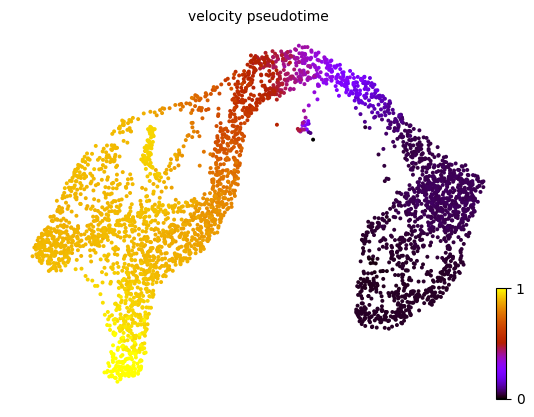

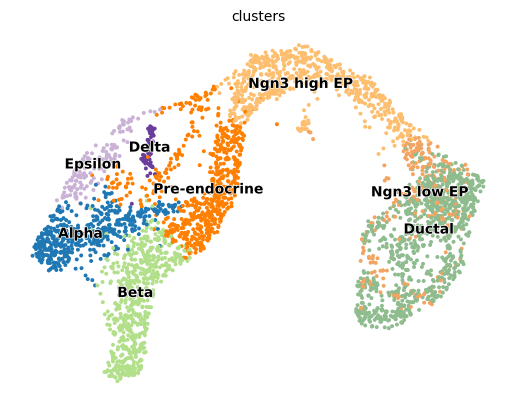

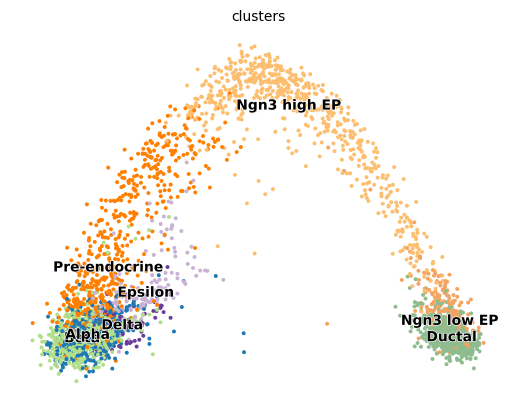

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


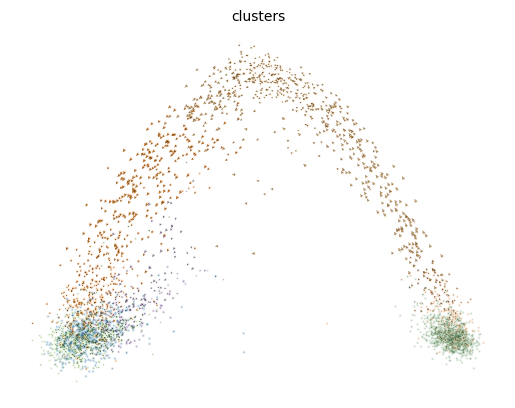

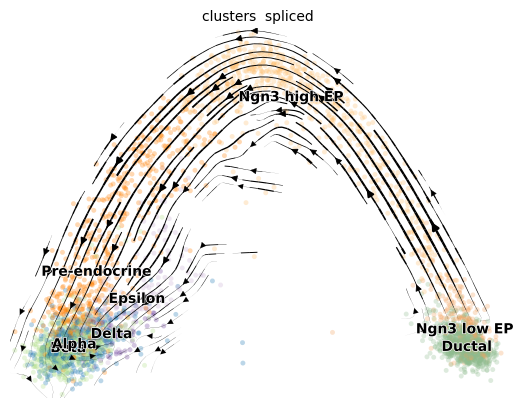

In [20]:
scv.tl.velocity_pseudotime(adata)
scv.pl.scatter(adata, basis='umap',color='velocity_pseudotime', color_map='gnuplot')
# scv.tl.latent_time(adata)
# scv.pl.scatter(adata, basis='pca',color='latent_time', color_map='jet', size=80)
scv.pl.scatter(adata, basis='umap',color='clusters')
scv.pl.scatter(adata, basis='pca',color='clusters')
scv.pl.velocity_embedding(adata, basis='pca',color='clusters')

scv.pl.velocity_embedding_stream(adata, basis='pca',color='clusters',s=50,layer='spliced',color_map='jet')

saving figure to file ./figures/scvelo_EG_vgraph.png


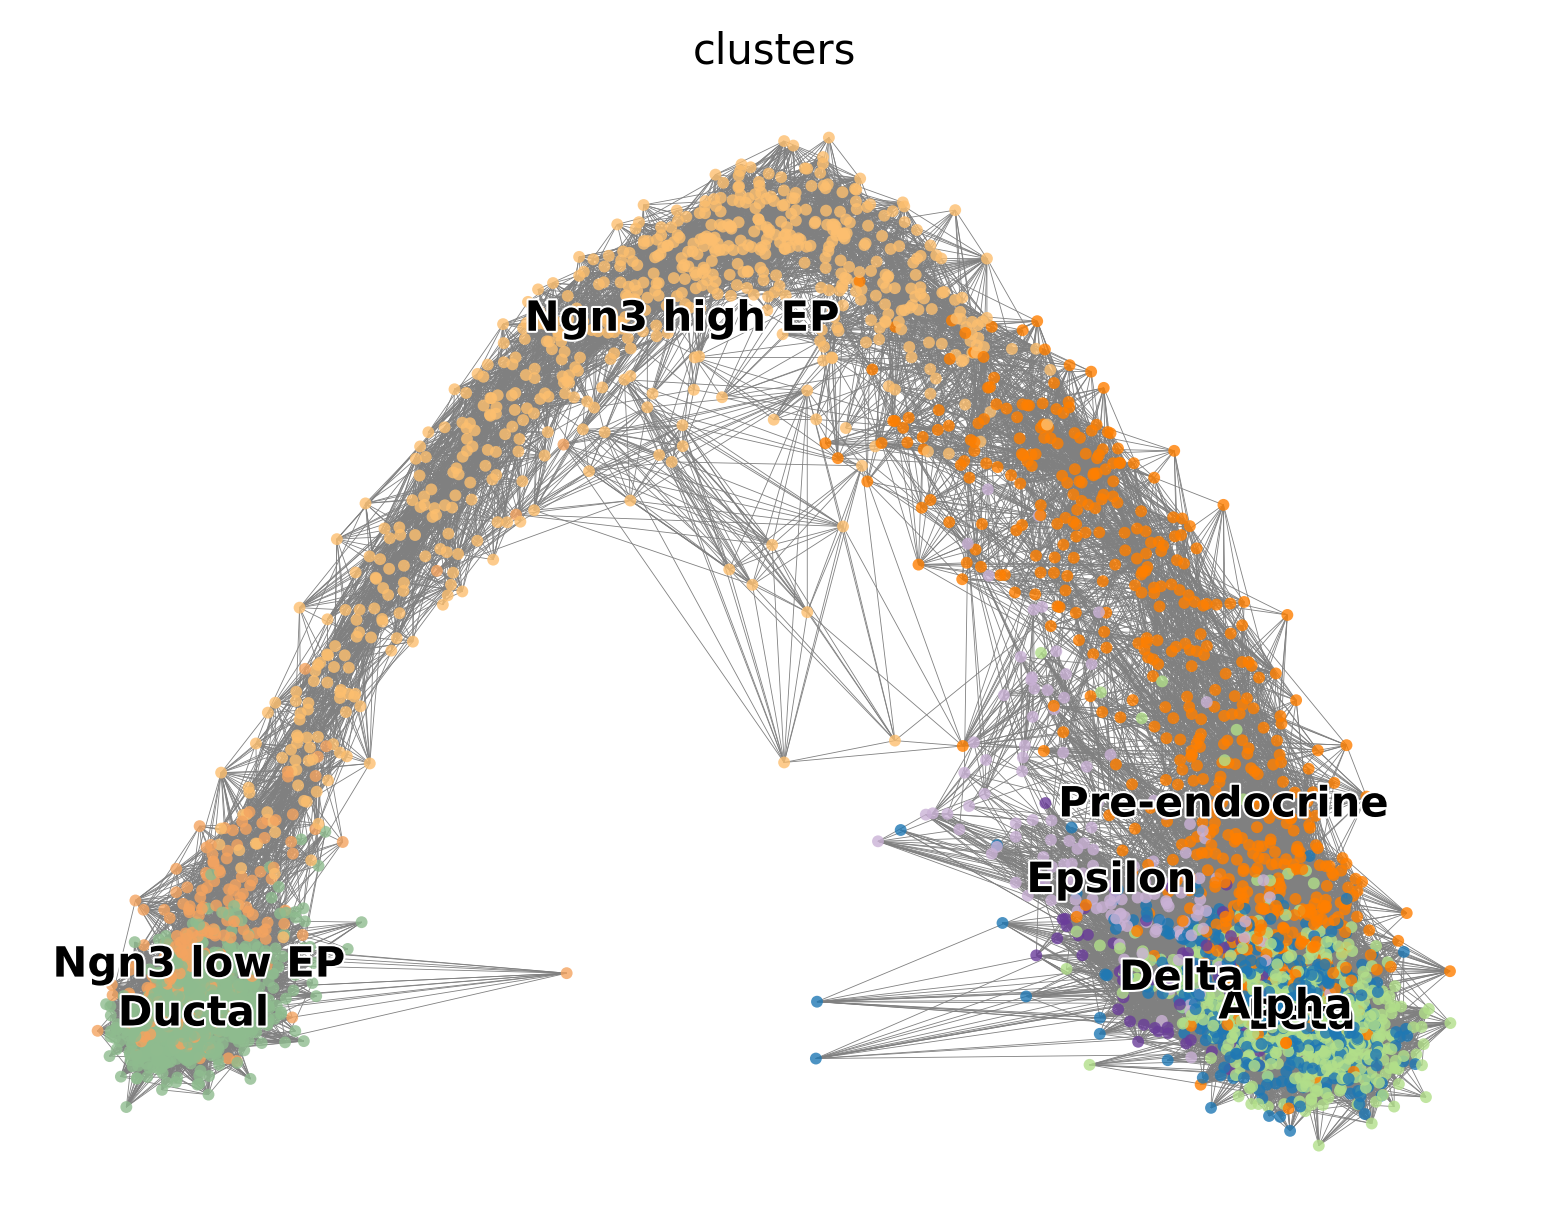

In [21]:
adata.obsm['X_pca'][:,0]=-adata.obsm['X_pca'][:,0]
scv.pl.velocity_graph(adata, basis='pca',color='clusters',dpi=300,save='EG_vgraph.png')

In [22]:
adata.write_h5ad(result_path+'EG_bin.h5ad')#h5ad save all features

In [23]:
adata0_sel=adata0[:,EG_bin_genes]
adata0_sel.write_h5ad(result_path+'EG_ori_bin.h5ad')
adata0_sel

View of AnnData object with n_obs × n_vars = 3696 × 737
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'